In [33]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple
import matplotlib as mpl

In [34]:
# настройки 
financial_path = "financial_data.csv"
prolongations_path = "prolongations.csv"
ANALYSIS_YEAR = 2023
pd.options.display.float_format = '{:,.2f}'.format

In [35]:
# Загрузка и чистка 
financial = pd.read_csv(financial_path)
prolong = pd.read_csv(prolongations_path)

financial = financial.dropna(how="all")
if "id" in financial.columns:
    financial = financial[financial["id"].notna()]
    financial["id"] = pd.to_numeric(financial["id"], errors="coerce")
    financial = financial[financial["id"].notna()]
    financial["id"] = financial["id"].astype(int)

prolong = prolong.dropna(how="all")
if "id" in prolong.columns:
    prolong = prolong[prolong["id"].notna()]
    prolong["id"] = pd.to_numeric(prolong["id"], errors="coerce")
    prolong = prolong[prolong["id"].notna()]
    prolong["id"] = prolong["id"].astype(int)

ru_month_map = {
    "январь": "01", "янв": "01",
    "февраль": "02", "фев": "02",
    "март": "03", "мар": "03",
    "апрель": "04", "апр": "04",
    "май": "05",
    "июнь": "06", "июн": "06",
    "июль": "07", "июл": "07",
    "август": "08", "авг": "08",
    "сентябрь": "09", "сент": "09", "сен": "09",
    "октябрь": "10", "окт": "10",
    "ноябрь": "11", "ноя": "11",
    "декабрь": "12", "дек": "12",
}
def norm_header_month(col: str) -> str:
    s = str(col).strip().lower().replace(".", "")
    m = re.match(r"^([а-яё]+)\s+(\d{4})$", s)
    if m:
        mon, year = m.group(1), m.group(2)
        if mon in ru_month_map: return f"{year}-{ru_month_map[mon]}"
    m = re.match(r"^([а-яё]+)(\d{4})$", s)
    if m:
        mon, year = m.group(1), m.group(2)
        if mon in ru_month_map: return f"{year}-{ru_month_map[mon]}"
    if re.match(r"^\d{4}-\d{2}$", s): return s
    return col

financial.columns = [norm_header_month(c) for c in financial.columns]
def is_month_col(name: str) -> bool:
    return bool(re.match(r"^\d{4}-\d{2}$", str(name)))
month_cols = [c for c in financial.columns if is_month_col(c)]


if len(month_cols) != len(set(month_cols)):
    non_m = [c for c in financial.columns if c not in month_cols]
    grouped = {}
    for c in set(month_cols):
        same = [col for col in month_cols if col == c]
        grouped[c] = financial[same].apply(pd.to_numeric, errors="coerce").sum(axis=1, min_count=1)
    financial = pd.concat([financial[non_m]] + [grouped[c].rename(c) for c in sorted(grouped.keys())], axis=1)
    month_cols = [c for c in financial.columns if is_month_col(c)]


if "month" in prolong.columns:
    prolong["month"] = prolong["month"].apply(norm_header_month)


fin_long = financial.melt(
    id_vars=[c for c in financial.columns if c not in month_cols],
    value_vars=month_cols,
    var_name="month",
    value_name="amount_raw"
)

fin_long["amount_str"] = fin_long["amount_raw"].astype(str).str.strip().str.lower()
fin_long["is_stop"] = fin_long["amount_str"].isin(["стоп", "end"])
fin_long["is_v_nol"] = fin_long["amount_str"].eq("в ноль")

def normalize_number_string(s: pd.Series) -> pd.Series:
    return (
        s.str.replace("\u00a0", "", regex=False)   
         .str.replace(" ", "", regex=False)        
         .str.replace(",", ".", regex=False)       
    )

fin_long["amount_num"] = pd.to_numeric(normalize_number_string(fin_long["amount_str"]), errors="coerce")


prolong_clean = prolong.rename(columns={"month": "last_month", "AM": "AM_primary"}).copy()
fin_l = fin_long.merge(prolong_clean[["id", "last_month", "AM_primary"]], on="id", how="left")
fin_l = fin_l[fin_l["last_month"].notna()].copy()

In [36]:
# Исключаем стоп и end
fin_l["month_period"] = pd.PeriodIndex(fin_l["month"], freq="M")
fin_l["last_period"] = pd.PeriodIndex(fin_l["last_month"].fillna("1900-01"), freq="M")

stop_flags = (
    fin_l[fin_l["is_stop"]]
    .assign(le_last=lambda d: d["month_period"] <= d["last_period"])
    .groupby("id", as_index=False)["le_last"]
    .max()
    .rename(columns={"le_last": "stop_before_or_in_last"})
)
fin_l = fin_l.merge(stop_flags, on="id", how="left")
fin_l["stop_before_or_in_last"] = fin_l["stop_before_or_in_last"].astype("boolean").fillna(False)
fin_l = fin_l[~fin_l["stop_before_or_in_last"]].copy()


fin_l["amount_effective"] = fin_l["amount_num"].fillna(0.0)

tmp = fin_l[["id", "AM_primary", "month", "amount_effective", "is_v_nol"]].copy()
agg = tmp.groupby(["id", "month"], as_index=False).agg(
    AM_primary=("AM_primary", "first"),
    amount_effective=("amount_effective", "sum"),
    is_v_nol=("is_v_nol", "max"),
)
rev = agg.copy()
rev_by = rev.set_index(["id", "month"]).sort_index()

def prev_month_str(m: str) -> str:
    return (pd.Period(m, freq="M") - 1).strftime("%Y-%m")

def amount_for(id_list, month):
    if not id_list:
        return pd.DataFrame(columns=["id", "month", "amount_effective"])
    idx = pd.MultiIndex.from_product([id_list, [month]], names=["id", "month"])
    vals = rev_by.reindex(idx)["amount_effective"].fillna(0.0).to_frame("amount_effective").reset_index()
    return vals

def is_v_nol_for(id_list, month):
    if not id_list:
        return pd.DataFrame(columns=["id", "month", "is_v_nol"])
    idx = pd.MultiIndex.from_product([id_list, [month]], names=["id", "month"])
    s = rev_by.reindex(idx)["is_v_nol"]
    s = s.astype("boolean").fillna(False)
    vals = s.to_frame("is_v_nol").reset_index()
    return vals


In [37]:
# Расчёт K1, K2
id_meta = prolong_clean[["id", "last_month", "AM_primary"]].drop_duplicates()

months_fin = set(rev["month"].unique())
months_last = set(prolong_clean["last_month"].unique())

months_for_kpi = []
for m in sorted(months_fin):
    p = pd.Period(m, freq="M")
    if p.year != ANALYSIS_YEAR:
        continue
    m1 = (p - 1).strftime("%Y-%m")
    if (m in months_fin) and (m1 in months_fin) and (m1 in months_last):
        months_for_kpi.append(m)

rows_am, rows_dep = [], []

for M in months_for_kpi:
    M_minus_1 = prev_month_str(M)
    M_minus_2 = prev_month_str(M_minus_1)

    # К1 база
    base_k1 = id_meta[id_meta["last_month"].eq(M_minus_1)].copy()
    ids_k1 = base_k1["id"].tolist()
    denom_k1_df = amount_for(ids_k1, M_minus_1).rename(columns={"amount_effective": "denom"})
    v_nol_k1_df = is_v_nol_for(ids_k1, M_minus_1)
    denom_k1 = denom_k1_df.merge(v_nol_k1_df, on=["id", "month"], how="left")
    prev_for_k1 = amount_for(ids_k1, M_minus_2).rename(columns={"amount_effective": "prev_amount"})
    denom_k1 = denom_k1.merge(prev_for_k1[["id", "prev_amount"]], on="id", how="left")
    denom_k1["denom_adj"] = np.where(
        (denom_k1["is_v_nol"]) & (denom_k1["denom"].fillna(0) == 0),
        denom_k1["prev_amount"].fillna(0),
        denom_k1["denom"].fillna(0)
    )
    num_k1_df = amount_for(ids_k1, M).rename(columns={"amount_effective": "num"})
    k1_df = base_k1.merge(denom_k1[["id", "denom_adj"]], on="id", how="left") \
                   .merge(num_k1_df[["id", "num"]], on="id", how="left")
    k1_df["denom_adj"] = k1_df["denom_adj"].fillna(0.0); k1_df["num"] = k1_df["num"].fillna(0.0)

    # K2 база
    base_k2 = id_meta[id_meta["last_month"].eq(M_minus_2)].copy()
    ids_k2 = base_k2["id"].tolist()
    amt_m1_k2 = amount_for(ids_k2, M_minus_1).rename(columns={"amount_effective": "amt_m1"})
    no_m1_ids = amt_m1_k2[amt_m1_k2["amt_m1"].fillna(0.0) == 0.0]["id"].unique().tolist()
    base_k2 = base_k2[base_k2["id"].isin(no_m1_ids)].copy()
    ids_k2_final = base_k2["id"].tolist()

    M_minus_3 = prev_month_str(M_minus_2)
    denom_k2_df = amount_for(ids_k2_final, M_minus_2).rename(columns={"amount_effective": "denom"})
    v_nol_k2_df = is_v_nol_for(ids_k2_final, M_minus_2)
    denom_k2 = denom_k2_df.merge(v_nol_k2_df, on=["id", "month"], how="left")
    prev_for_k2 = amount_for(ids_k2_final, M_minus_3).rename(columns={"amount_effective": "prev_amount"})
    denom_k2 = denom_k2.merge(prev_for_k2[["id", "prev_amount"]], on="id", how="left")
    denom_k2["denom_adj"] = np.where(
        (denom_k2["is_v_nol"]) & (denom_k2["denom"].fillna(0) == 0),
        denom_k2["prev_amount"].fillna(0),
        denom_k2["denom"].fillna(0)
    )
    num_k2_df = amount_for(ids_k2_final, M).rename(columns={"amount_effective": "num"})
    k2_df = base_k2.merge(denom_k2[["id", "denom_adj"]], on="id", how="left") \
                   .merge(num_k2_df[["id", "num"]], on="id", how="left")
    k2_df["denom_adj"] = k2_df["denom_adj"].fillna(0.0); k2_df["num"] = k2_df["num"].fillna(0.0)

    # Агрегации
    def agg_rates(df_ids: pd.DataFrame, label: str) -> Tuple[pd.DataFrame, pd.Series]:
        if df_ids.empty:
            return pd.DataFrame(columns=["AM_primary", "denom", "num", "rate", "label", "month"]), pd.Series(dtype=float)
        ag = df_ids.groupby("AM_primary", as_index=False).agg(denom=("denom_adj", "sum"),
                                                             num=("num", "sum"))
        ag["rate"] = np.where(ag["denom"] > 0, ag["num"]/ag["denom"], np.nan)
        ag["label"] = label; ag["month"] = M
        dep = pd.Series({"denom": ag["denom"].sum(),
                         "num": ag["num"].sum(),
                         "rate": (ag["num"].sum()/ag["denom"].sum()) if ag["denom"].sum() > 0 else np.nan,
                         "label": label, "month": M})
        return ag, dep

    k1_ag, k1_dep = agg_rates(k1_df, "K1")
    k2_ag, k2_dep = agg_rates(k2_df, "K2")
    rows_am += [k1_ag, k2_ag]; rows_dep += [k1_dep, k2_dep]

am_monthly = pd.concat(rows_am, ignore_index=True) if rows_am else pd.DataFrame()
dep_monthly = pd.DataFrame(rows_dep)


In [38]:
# Годовые коэффициенты 
def annual_rates_am(df: pd.DataFrame, year: int) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["AM_primary", "label", "year", "denom", "num", "rate"])
    df_y = df[df["month"].str.startswith(str(year))]
    ag = df_y.groupby(["AM_primary", "label"], as_index=False).agg(denom=("denom", "sum"),
                                                                  num=("num", "sum"))
    ag["year"] = year; ag["rate"] = np.where(ag["denom"] > 0, ag["num"]/ag["denom"], np.nan)
    return ag

def annual_rates_dep(df: pd.DataFrame, year: int) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["label", "year", "denom", "num", "rate"])
    df_y = df[df["month"].str.startswith(str(year))]
    ag = df_y.groupby(["label"], as_index=False).agg(denom=("denom", "sum"),
                                                     num=("num", "sum"))
    ag["year"] = year; ag["rate"] = np.where(ag["denom"] > 0, ag["num"]/ag["denom"], np.nan)
    return ag

am_annual = annual_rates_am(am_monthly, ANALYSIS_YEAR)
dep_annual = annual_rates_dep(dep_monthly, ANALYSIS_YEAR)

In [39]:
sns.set(style="whitegrid")
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["figure.figsize"] = (12, 5)
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 11

def safe_caption(st, text):
    return st.set_caption(str(text))

def fmt_pct_clean(x):
    return "" if pd.isna(x) else f"{x:.1%}"

# Отделы K1 и K2 по месяцам с базой
dept_k1 = dep_monthly[(dep_monthly["label"]=="K1") & (dep_monthly["denom"]>0)].copy()
dept_k2 = dep_monthly[(dep_monthly["label"]=="K2") & (dep_monthly["denom"]>0)].copy()
dept_k1_p = dept_k1.pivot(index="month", columns="label", values="rate")
dept_k2_p = dept_k2.pivot(index="month", columns="label", values="rate")

display(safe_caption(dept_k1_p.style.format("{:.1%}"), f"Отдел: K1 по месяцам (только с базой), {ANALYSIS_YEAR}"))
display(safe_caption(dept_k2_p.style.format("{:.1%}"), f"Отдел: K2 по месяцам (только с базой), {ANALYSIS_YEAR}"))

label,K1
month,
2023-01,59.9%
2023-02,86.8%
2023-03,79.2%
2023-04,61.1%
2023-05,61.3%
2023-06,42.1%
2023-07,68.4%
2023-08,69.4%
2023-09,29.7%


label,K2
month,
2023-01,22.0%
2023-02,15.5%
2023-03,27.7%
2023-04,27.3%
2023-05,0.0%
2023-06,6.5%
2023-07,12.7%
2023-08,4.8%
2023-09,0.0%


In [40]:
# K1: видно пик в феврале и октябре и просадку в сентябре- это показывает месяцы сильной и слабой работы команды
# K2: второй месяц даёт меньше продлений и колеблется сильнее; низкие значения означают, 
# что основную часть успеваем  продлить сразу в первый месяц.

In [41]:
# AM * месяц и фильтруем по базе
def filter_pivot_by_base(am_df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = am_df[am_df["label"] == label].copy()
    base = df.pivot(index="AM_primary", columns="month", values="denom").fillna(0.0)
    rates = df.pivot(index="AM_primary", columns="month", values="rate")
    mask = base > 0
    rates_clean = rates.where(mask)
    rates_clean = rates_clean.dropna(axis=0, how="all").dropna(axis=1, how="all")
    return rates_clean

k1_clean = filter_pivot_by_base(am_monthly, "K1")
k2_clean = filter_pivot_by_base(am_monthly, "K2")

display(safe_caption(k1_clean.style.format(fmt_pct_clean), "K1 по AM*месяц"))
display(safe_caption(k2_clean.style.format(fmt_pct_clean), "K2 по AM*месяц"))

month,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
AM_primary,,,,,,,,,,,,
Васильев Артем Александрович,71.3%,110.4%,76.5%,24.2%,40.1%,60.4%,57.9%,75.4%,21.2%,137.9%,67.9%,37.2%
Иванова Мария Сергеевна,33.8%,,80.1%,52.0%,100.0%,0.0%,61.4%,82.1%,100.0%,,,
Кузнецов Михаил Иванович,126.6%,84.7%,,0.0%,,,,,,130.9%,92.7%,54.0%
Михайлов Андрей Сергеевич,78.6%,82.5%,243.1%,106.8%,111.2%,0.0%,119.8%,,0.0%,65.1%,,0.0%
Петрова Анна Дмитриевна,,,,,,,,,,,,111.1%
Попова Екатерина Николаевна,76.8%,0.0%,81.2%,24.1%,93.9%,0.0%,15.8%,59.5%,74.7%,105.6%,,60.0%
Смирнова Ольга Владимировна,89.8%,0.0%,,96.6%,,0.0%,0.0%,53.6%,88.7%,106.9%,91.4%,47.5%
Соколова Анастасия Викторовна,64.5%,16.4%,92.1%,119.1%,41.7%,92.4%,95.6%,66.7%,19.0%,103.9%,27.1%,92.2%


month,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
AM_primary,,,,,,,,,,,,
Васильев Артем Александрович,0.0%,23.0%,103.8%,32.4%,0.0%,9.0%,0.0%,0.0%,0.0%,7.4%,0.0%,33.3%
Иванова Мария Сергеевна,0.0%,0.0%,,0.0%,0.0%,,0.0%,0.0%,0.0%,,,
Кузнецов Михаил Иванович,,,,,0.0%,,,,,,,
Михайлов Андрей Сергеевич,0.0%,0.0%,,,,,0.0%,,,0.0%,0.0%,
Попова Екатерина Николаевна,0.0%,0.0%,0.0%,43.4%,0.0%,0.0%,51.5%,0.0%,0.0%,0.0%,43.9%,
Смирнова Ольга Владимировна,,0.0%,115.1%,,,,51.6%,155.3%,0.0%,0.0%,0.0%,38.2%
Соколова Анастасия Викторовна,82.4%,29.4%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


In [42]:
# K1 у ряда менеджеров держится стабильно высоким, 
# а K2 встречается реже и ниже, значит основную часть продлеваем сразу в первый месяц, а второй месяц это точечные догонки

In [43]:
# Топ AM за год 
am_annual_clean = am_annual[am_annual["denom"] > 0].copy()

top_k1_year = (am_annual_clean[am_annual_clean["label"]=="K1"]
               .sort_values("rate", ascending=False)[["AM_primary","denom","num","rate"]])
top_k2_year = (am_annual_clean[am_annual_clean["label"]=="K2"]
               .sort_values("rate", ascending=False)[["AM_primary","denom","num","rate"]])

display(safe_caption(
    top_k1_year.style.format({"denom":"{:,.0f}","num":"{:,.0f}","rate":"{:.1%}"}),
    f"Топ AM по K1 за {ANALYSIS_YEAR} (база > 0)"
))
display(safe_caption(
    top_k2_year.style.format({"denom":"{:,.0f}","num":"{:,.0f}","rate":"{:.1%}"}),
    f"Топ AM по K2 за {ANALYSIS_YEAR} (база > 0)"
))

,AM_primary,denom,num,rate
8,Петрова Анна Дмитриевна,"98,492","109,443",111.1%
11,Смирнова Ольга Владимировна,"11,441,172","10,717,802",93.7%
9,Попова Екатерина Николаевна,"12,074,116","10,811,420",89.5%
4,Кузнецов Михаил Иванович,"1,674,906","1,400,203",83.6%
13,Соколова Анастасия Викторовна,"16,376,469","12,768,090",78.0%
6,Михайлов Андрей Сергеевич,"8,564,802","6,344,665",74.1%
0,Васильев Артем Александрович,"31,358,309","20,062,461",64.0%
2,Иванова Мария Сергеевна,"10,915,387","5,481,271",50.2%


,AM_primary,denom,num,rate
12,Смирнова Ольга Владимировна,"1,192,492","335,355",28.1%
1,Васильев Артем Александрович,"10,950,077","1,371,916",12.5%
10,Попова Екатерина Николаевна,"1,868,540","195,220",10.4%
14,Соколова Анастасия Викторовна,"4,221,890","292,455",6.9%
3,Иванова Мария Сергеевна,"3,076,957",0,0.0%
5,Кузнецов Михаил Иванович,"1,425",0,0.0%
7,Михайлов Андрей Сергеевич,"1,706,479",0,0.0%


In [44]:
# Таблица показывает годовой рейтинг - кто при реальной базе продлевает лучше по K1 и кто даёт наибольший вклад по K2; 
# таких людей можно поощрять и делиться их практиками с командой

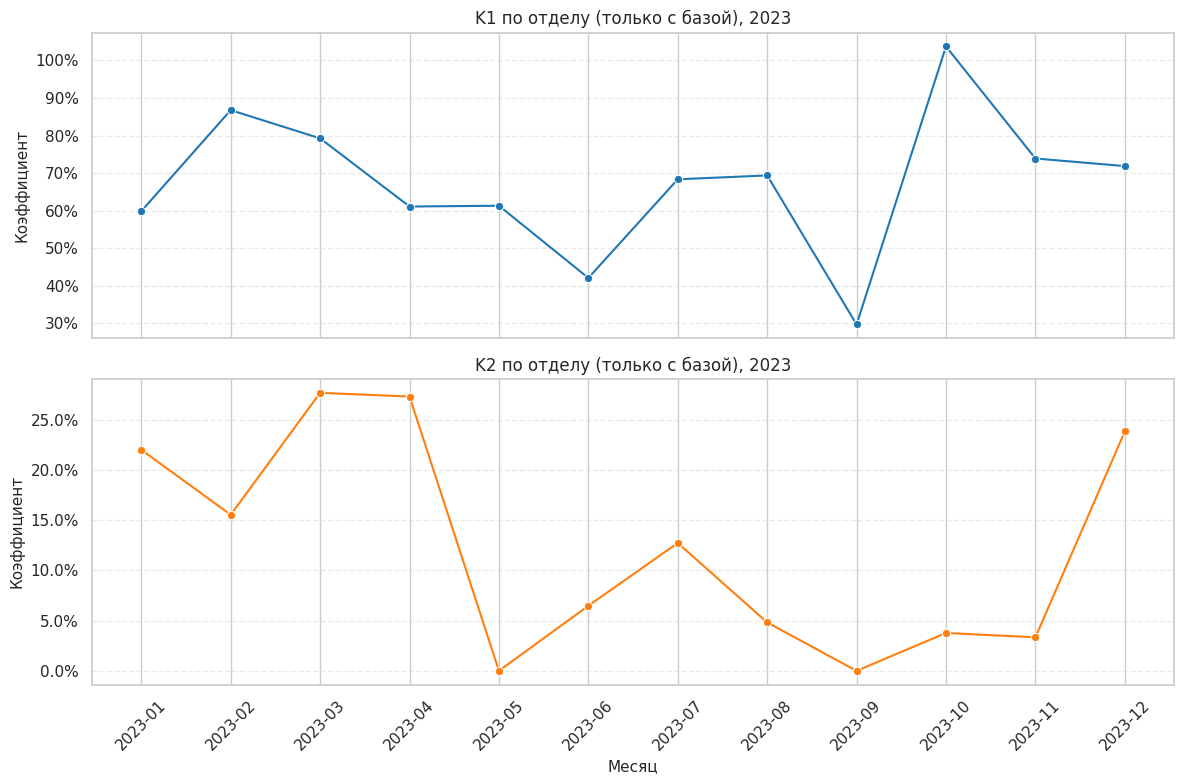

In [45]:
# графики по отделу 
dep_plot = dep_monthly.copy()
dep_plot["rate_plot"] = dep_plot["rate"].where(dep_plot["denom"]>0) 

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

d1 = dep_plot[(dep_plot["label"]=="K1") & (dep_plot["denom"]>0)].sort_values("month")
sns.lineplot(data=d1, x="month", y="rate_plot", marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title(f"K1 по отделу (только с базой), {ANALYSIS_YEAR}")
axes[0].set_ylabel("Коэффициент"); axes[0].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
axes[0].grid(True, axis="y", linestyle="--", alpha=0.4)

d2 = dep_plot[(dep_plot["label"]=="K2") & (dep_plot["denom"]>0)].sort_values("month")
sns.lineplot(data=d2, x="month", y="rate_plot", marker="o", ax=axes[1], color="#ff7f0e")
axes[1].set_title(f"K2 по отделу (только с базой), {ANALYSIS_YEAR}")
axes[1].set_xlabel("Месяц"); axes[1].set_ylabel("Коэффициент")
axes[1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [46]:
# K1: продления в первый месяц держатся в районе 60-80% с пиком в октябре и провалом в сентябре
# K2: ворой месяц заметно слабее и нестабилен, с единичными всплесками (март, декабрь)

In [52]:
#диагностика базы 
am_base = am_monthly.pivot_table(index="AM_primary", columns=["label","month"], values="denom", aggfunc="sum", fill_value=0.0)
am_base = am_base.loc[(am_base.sum(axis=1) > 0)]
am_base = am_base.loc[:, am_base.sum(axis=0) > 0]
display(safe_caption(am_base.style.format("{:,.0f}"), "База по AM*месяц"))

In [48]:
# Диагностика показывает "вес" задач по каждому
# менеджеру и месяцу, снимая вопросы по процентам: где база большая - именно там ждём результата

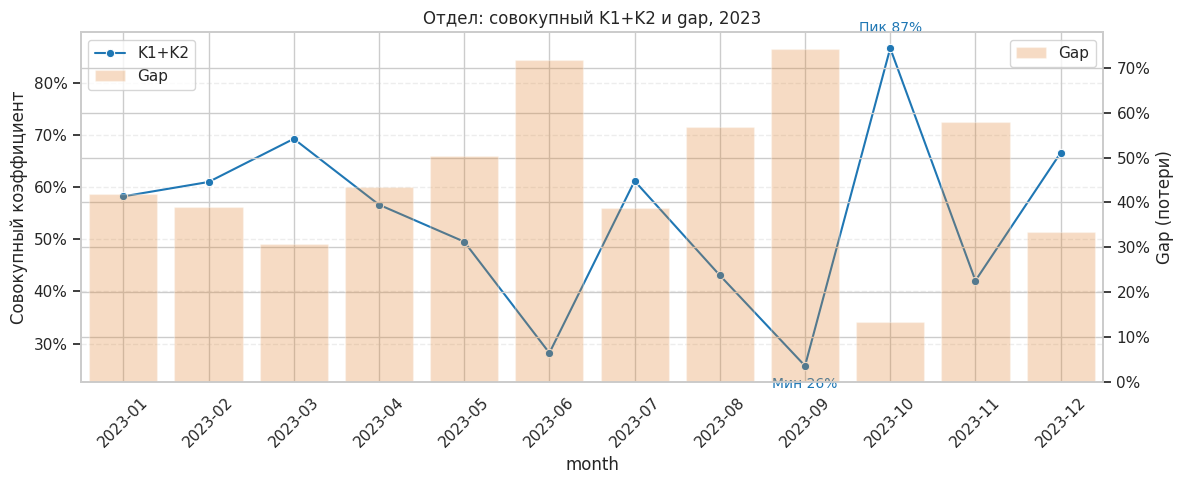

In [49]:
dept_k = (dep_monthly.groupby("month", as_index=False)
          .agg(denom=("denom","sum"), num=("num","sum")))
dept_k = dept_k[dept_k["denom"] > 0].copy()
dept_k["k12"] = dept_k["num"] / dept_k["denom"]
dept_k["gap"] = 1 - dept_k["k12"]
dept_k = dept_k.sort_values("month").reset_index(drop=True)

# Стиль
sns.set(style="whitegrid")
mpl.rcParams["figure.figsize"] = (12, 5)

# График
fig, ax1 = plt.subplots(figsize=(12,5))

# Линия K1+K2
sns.lineplot(data=dept_k, x="month", y="k12", marker="o", ax=ax1, color="#1f77b4", label="K1+K2")
ax1.set_ylabel("Совокупный коэффициент")
ax1.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, axis="y", linestyle="--", alpha=0.35)

# Столбцы gap на второй оси
ax2 = ax1.twinx()
sns.barplot(data=dept_k, x="month", y="gap", ax=ax2, alpha=0.28, color="#ff7f0e", label="Gap")
ax2.set_ylabel("Gap (потери)")
ax2.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))

# Общая легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=True)

# Аннотации пика и минимума K1+K2
imax = dept_k["k12"].idxmax()
imin = dept_k["k12"].idxmin()
ax1.annotate(f"Пик {dept_k.loc[imax,'k12']:.0%}",
             xy=(imax, dept_k.loc[imax,'k12']), xytext=(0,12),
             textcoords="offset points", color="#1f77b4", ha="center", fontsize=10)
ax1.annotate(f"Мин {dept_k.loc[imin,'k12']:.0%}",
             xy=(imin, dept_k.loc[imin,'k12']), xytext=(0,-16),
             textcoords="offset points", color="#1f77b4", ha="center", fontsize=10)

plt.title(f"Отдел: совокупный K1+K2 и gap, {ANALYSIS_YEAR}")
plt.tight_layout()
plt.show()

In [50]:
# Кривая K1+K2 держится в районе 60-70% большую часть года, проваливается летом 
# (июнь-сентябрь) и резко взлетает в октябре, а столбцы gap показывают 
# обратную картину: потери максимальны в слабые летние месяцы и минимальны в октябре